# Penguins dataset - simple EDA

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1. Load the data

In [4]:
df = pd.read_csv('data/penguins.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
df.info()

Rows: 344
Columns: 7
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


## 2. Summary statistics

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,344,3,Adelie,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
island,344,3,Biscoe,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bill_length_mm,342.0,NaN,NaN,NaN,43.92193,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,NaN,NaN,NaN,17.15117,1.974793,13.1,15.6,17.3,18.7,21.5
flipper_length_mm,342.0,NaN,NaN,NaN,200.915205,14.061714,172.0,190.0,197.0,213.0,231.0
body_mass_g,342.0,NaN,NaN,NaN,4201.754386,801.954536,2700.0,3550.0,4050.0,4750.0,6300.0
sex,333,2,MALE,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing values

Some penguins have missing measurements or sex information.

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

sex                  11
bill_depth_mm         2
bill_length_mm        2
flipper_length_mm     2
body_mass_g           2
dtype: int64

## 4. Clean the data before plotting

For this simple EDA, remove rows with missing values. The original `df` stays unchanged for the missing-value analysis.

In [8]:
df_clean = df.dropna().copy()
print(f'Original rows: {len(df)}')
print(f'Rows after cleaning: {len(df_clean)}')
print(f'Rows removed: {len(df) - len(df_clean)}')
df_clean.isna().sum()

Original rows: 344
Rows after cleaning: 333
Rows removed: 11


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

## 5. Species and island counts

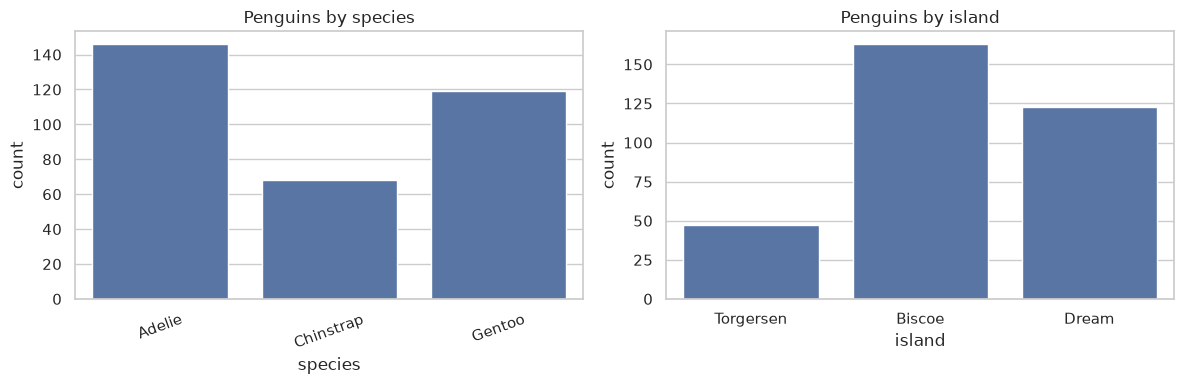

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df_clean, x='species', ax=axes[0])
axes[0].set_title('Penguins by species')
axes[0].tick_params(axis='x', rotation=20)
sns.countplot(data=df_clean, x='island', ax=axes[1])
axes[1].set_title('Penguins by island')
plt.tight_layout()

## 6. Compare body mass by species

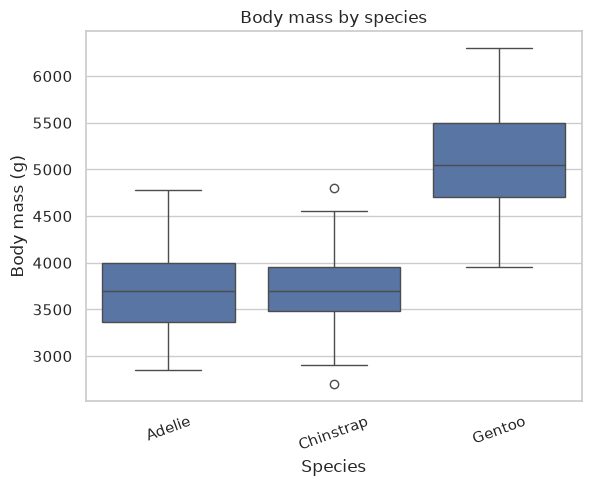

In [10]:
sns.boxplot(data=df_clean, x='species', y='body_mass_g')
plt.title('Body mass by species')
plt.xlabel('Species')
plt.ylabel('Body mass (g)')
plt.xticks(rotation=20)
plt.show()

## 7. Relationship between bill length and bill depth

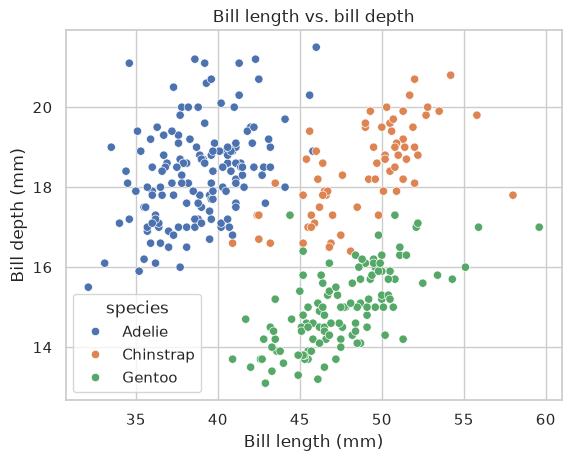

In [11]:
sns.scatterplot(data=df_clean, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title('Bill length vs. bill depth')
plt.xlabel('Bill length (mm)')
plt.ylabel('Bill depth (mm)')
plt.show()

## 8. Save the cleaned dataset

In [12]:
clean_path = 'data/penguins_clean.csv'
df_clean.to_csv(clean_path, index=False)
print(f'Saved cleaned dataset to {clean_path}')
print(f'Shape: {df_clean.shape}')

Saved cleaned dataset to data/penguins_clean.csv
Shape: (333, 7)
